# EX No. 04
# DEVELOPING A NEURAL NETWORK CLASSIFICATION MODEL USING TRANSFER LEARNING
**NAME**:HARINI G  **REG N0**:212225230091  **SLOT N0**:26OD1143

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import models, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [4]:
import zipfile

zip_path = "C:/Users/acer/Downloads/chip_data.zip"
extract_path = "./data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
dataset_path = "./data/dataset/"

train_dataset = datasets.ImageFolder(root=f"{dataset_path}/train",transform=transform)

test_dataset = datasets.ImageFolder(root=f"{dataset_path}/test",transform=transform)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

Classes: ['defect', 'notdefect']
Number of classes: 2


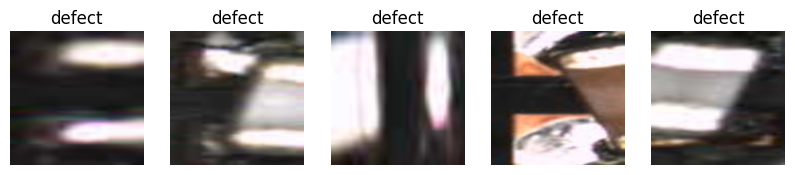

In [6]:
def show_sample_images(dataset, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))

    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0)

        axes[i].imshow(image)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.show()

show_sample_images(train_dataset)

In [7]:
print(f"Total number of training samples: {len(train_dataset)}")

first_image, label = train_dataset[0]
print(f"Shape of the first training image: {first_image.shape}")

print(f"Total number of testing samples: {len(test_dataset)}")

first_image1, label = test_dataset[0]
print(f"Shape of the first testing image: {first_image1.shape}")

Total number of training samples: 172
Shape of the first training image: torch.Size([3, 224, 224])
Total number of testing samples: 121
Shape of the first testing image: torch.Size([3, 224, 224])


In [8]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [10]:
from torchvision.models import VGG19_Weights

model = models.vgg19(weights=VGG19_Weights.DEFAULT)

print("VGG19 loaded successfully!")

VGG19 loaded successfully!


In [11]:
num_classes = len(train_dataset.classes)

in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(in_features,num_classes)

print("Number of classes:", num_classes)
print("Classes:", train_dataset.classes)
print("Final layer modified successfully!")

Number of classes: 2
Classes: ['defect', 'notdefect']
Final layer modified successfully!


In [12]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [13]:
from torchsummary import summary

summary(model,input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [14]:
for param in model.features.parameters():
    param.requires_grad = False

print("Feature extraction layers frozen successfully!")

Feature extraction layers frozen successfully!


In [15]:
criterion = nn.CrossEntropyLoss()

print("Loss function created successfully!")

Loss function created successfully!


In [16]:
optimizer = optim.Adam(model.classifier.parameters(),lr=0.001)

print("Optimizer created successfully!")

Optimizer created successfully!


In [17]:
model.eval()

def extract_features(loader):
    features = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            x = model.features(images)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)

            features.append(x.cpu())
            labels_list.append(labels)

    return torch.cat(features), torch.cat(labels_list)

train_features, train_labels = extract_features(train_loader)
test_features, test_labels = extract_features(test_loader)

print("Train features:", train_features.shape)
print("Test features:", test_features.shape)

Train features: torch.Size([172, 25088])
Test features: torch.Size([121, 25088])


In [18]:
classifier = nn.Linear(train_features.shape[1],num_classes)

classifier = classifier.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(classifier.parameters(),lr=0.001)

print("Classifier created successfully!")

Classifier created successfully!


In [19]:
train_features = train_features.to(device)
train_labels = train_labels.to(device)

for epoch in range(5):

    classifier.train()

    optimizer.zero_grad()

    outputs = classifier(train_features)

    loss = criterion(outputs, train_labels)

    loss.backward()

    optimizer.step()

    print(f"Epoch [{epoch+1}/5], "f"Loss: {loss.item():.4f}")

Epoch [1/5], Loss: 0.7360
Epoch [2/5], Loss: 1.0266
Epoch [3/5], Loss: 0.6023
Epoch [4/5], Loss: 0.1868
Epoch [5/5], Loss: 0.1674


In [20]:
classifier.eval()

test_features = test_features.to(device)
test_labels = test_labels.to(device)

with torch.no_grad():

    outputs = classifier(test_features)

    _, predicted = torch.max(outputs, 1)

accuracy = ((predicted == test_labels).sum().item()/ len(test_labels))

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 0.9008
Test Accuracy: 90.08%


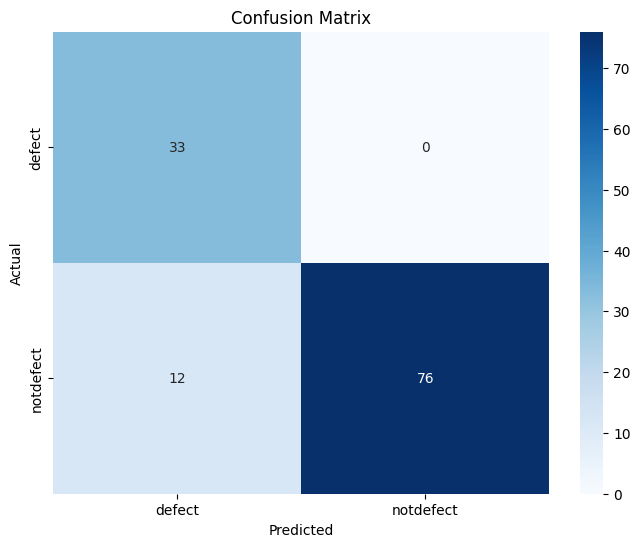

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(test_labels.cpu().numpy(),predicted.cpu().numpy())

plt.figure(figsize=(8, 6))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=train_dataset.classes,yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
print("Name: HARINI G")
print("Register Number: 212225230091")

print("\nClassification Report:")

print(classification_report(test_labels.cpu().numpy(),predicted.cpu().numpy(),target_names=train_dataset.classes))

Name: HARINI G
Register Number: 212225230091

Classification Report:
              precision    recall  f1-score   support

      defect       0.73      1.00      0.85        33
   notdefect       1.00      0.86      0.93        88

    accuracy                           0.90       121
   macro avg       0.87      0.93      0.89       121
weighted avg       0.93      0.90      0.90       121



In [23]:
def predict_image_fast(image_index, dataset):

    image, label = dataset[image_index]

    # Extract VGG19 features
    model.eval()

    with torch.no_grad():
        image_tensor = image.unsqueeze(0).to(device)

        features = model.features(image_tensor)
        features = model.avgpool(features)
        features = torch.flatten(features, 1)

        # Use trained classifier
        output = classifier(features)

        _, predicted = torch.max(output, 1)
        predicted = predicted.item()

    class_names = dataset.classes

    # Display image
    image_to_display = transforms.ToPILImage()(image)

    plt.figure(figsize=(4, 4))
    plt.imshow(image_to_display)

    plt.title(f"Actual: {class_names[label]}\n"f"Predicted: {class_names[predicted]}")

    plt.axis("off")
    plt.show()

    print(f"Actual: {class_names[label]}")
    print(f"Predicted: {class_names[predicted]}")

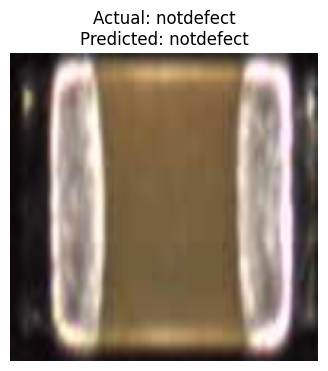

Actual: notdefect
Predicted: notdefect


In [24]:
predict_image_fast(55, test_dataset)